In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import optuna

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
# Load data and filter article

df = pd.read_csv("../data_raw/date_24_art_loreal_20%.csv")
df = df[df["ID_ARTICOL"] == 147807]

# Ensure datetime and sort
if df["DATA"].dtype != 'datetime64[ns]':
    df["DATA"] = pd.to_datetime(df["DATA"], errors="coerce")

df = df.sort_values("DATA").reset_index(drop=True)


C:\Users\Mara\AppData\Local\Temp\ipykernel_25184\3046016029.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATA"] = pd.to_datetime(df["DATA"], errors="coerce")


In [3]:
# Feature engineering (replica xgboost_model.py)
df_feat = df.copy()

# temporal features
df_feat['DOW'] = df_feat['DATA'].dt.dayofweek
df_feat['month'] = df_feat['DATA'].dt.month
df_feat['ESTE_WEEKEND'] = (df_feat['DOW'] >= 5).astype(int)
df_feat['ZI_DIN_LUNA'] = df_feat['DATA'].dt.day
df_feat['week'] = df_feat['DATA'].dt.isocalendar().week

# lag features (target)
for lag in [1, 7, 14]:
    df_feat[f'lag_{lag}'] = df_feat['CANTITATE'].shift(lag)

# rolling features (shifted to avoid leakage)
for window in [7, 14]:
    df_feat[f'roll_mean_{window}'] = df_feat['CANTITATE'].shift(1).rolling(window).mean()
    df_feat[f'roll_std_{window}'] = df_feat['CANTITATE'].shift(1).rolling(window).std()
    df_feat[f'roll_max_{window}'] = df_feat['CANTITATE'].shift(1).rolling(window).max()
    df_feat[f'roll_min_{window}'] = df_feat['CANTITATE'].shift(1).rolling(window).min()

# extra feature: VAL_IESIRE_FARA_TVA (lag + rolling, shifted)
if 'VAL_IESIRE_FARA_TVA' in df_feat.columns:
    for lag in [1, 7, 14]:
        df_feat[f'VAL_IESIRE_FARA_TVA_lag{lag}'] = df_feat['VAL_IESIRE_FARA_TVA'].shift(lag)
    for window in [7, 14]:
        shifted = df_feat['VAL_IESIRE_FARA_TVA'].shift(1)
        df_feat[f'VAL_IESIRE_FARA_TVA_roll_mean_{window}'] = shifted.rolling(window).mean()
        df_feat[f'VAL_IESIRE_FARA_TVA_roll_std_{window}'] = shifted.rolling(window).std()

feature_cols = [
    'DOW', 'month', 'ESTE_WEEKEND', 'ZI_DIN_LUNA', 'week',
    'lag_1', 'lag_7', 'lag_14',
    'roll_mean_7', 'roll_std_7', 'roll_max_7', 'roll_min_7',
    'roll_mean_14', 'roll_std_14', 'roll_max_14', 'roll_min_14'
]
if 'VAL_IESIRE_FARA_TVA' in df_feat.columns:
    feature_cols += [
        'VAL_IESIRE_FARA_TVA_lag1', 'VAL_IESIRE_FARA_TVA_lag7', 'VAL_IESIRE_FARA_TVA_lag14',
        'VAL_IESIRE_FARA_TVA_roll_mean_7', 'VAL_IESIRE_FARA_TVA_roll_std_7',
        'VAL_IESIRE_FARA_TVA_roll_mean_14', 'VAL_IESIRE_FARA_TVA_roll_std_14'
    ]

# drop raw VAL_IESIRE_FARA_TVA to avoid same-day leakage
if 'VAL_IESIRE_FARA_TVA' in df_feat.columns:
    df_feat = df_feat.drop(columns=['VAL_IESIRE_FARA_TVA'])

# drop rows with NaNs from lag/rolling
df_feat = df_feat.dropna(subset=feature_cols + ['CANTITATE'])


In [4]:
df_feat

,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,...,roll_std_14,roll_max_14,roll_min_14,VAL_IESIRE_FARA_TVA_lag1,VAL_IESIRE_FARA_TVA_lag7,VAL_IESIRE_FARA_TVA_lag14,VAL_IESIRE_FARA_TVA_roll_mean_7,VAL_IESIRE_FARA_TVA_roll_std_7,VAL_IESIRE_FARA_TVA_roll_mean_14,VAL_IESIRE_FARA_TVA_roll_std_14
14,2024-01-15,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,14,980.0,731.50,0.0,0.0,91.97,287,...,4.480115,16.0,0.0,941.18,235.28,0.00,529.400000,235.302500,466.370000,263.532911
15,2024-01-16,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,490.0,365.75,0.0,0.0,46.05,273,...,4.122439,16.0,0.0,823.47,647.04,0.00,613.427143,217.083035,525.189286,242.491595
16,2024-01-17,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,8,560.0,418.00,0.0,0.0,52.58,266,...,3.298351,16.0,4.0,411.80,470.57,647.00,579.821429,228.899009,554.603571,194.016018
17,2024-01-18,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,13,910.0,679.25,0.0,0.0,85.45,258,...,3.285834,16.0,4.0,470.58,647.07,647.04,579.822857,228.898213,542.002143,193.281085
18,2024-01-19,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,9,630.0,470.25,0.0,0.0,59.15,245,...,3.410552,16.0,4.0,764.70,352.93,588.22,596.627143,238.763148,550.406429,200.618476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,507.5,365.75,0.0,0.0,53.69,1429,...,4.990100,16.0,0.0,719.02,119.84,119.84,291.032857,273.331503,410.873571,299.001358
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.0,0.00,0.0,0.0,0.00,1422,...,4.790673,16.0,0.0,419.44,0.00,479.35,333.832857,265.398815,432.273571,287.051987
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.0,0.00,0.0,0.0,0.00,1422,...,5.153149,16.0,0.0,0.00,0.00,359.52,333.832857,265.398815,398.034286,308.771338
733,2026-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,13,942.5,679.25,0.0,0.0,99.71,1422,...,5.451585,16.0,0.0,0.00,359.52,838.88,333.832857,265.398815,372.354286,326.653437


In [5]:
# Train/test split: last 30 days as test

forecast_horizon_daily = 14
if len(df_feat) <= forecast_horizon_daily:
    raise ValueError("Not enough data after feature engineering for 14-day split")

cutoff_date = df_feat["DATA"].iloc[-forecast_horizon_daily]
train_df = df_feat[df_feat["DATA"] < cutoff_date].copy()
test_df = df_feat[df_feat["DATA"] >= cutoff_date].copy()

print("Train rows:", len(train_df), "Test rows:", len(test_df))


Train rows: 707 Test rows: 14


In [6]:
train_df[feature_cols]

,DOW,month,ESTE_WEEKEND,ZI_DIN_LUNA,week,lag_1,lag_7,lag_14,roll_mean_7,roll_std_7,...,roll_std_14,roll_max_14,roll_min_14,VAL_IESIRE_FARA_TVA_lag1,VAL_IESIRE_FARA_TVA_lag7,VAL_IESIRE_FARA_TVA_lag14,VAL_IESIRE_FARA_TVA_roll_mean_7,VAL_IESIRE_FARA_TVA_roll_std_7,VAL_IESIRE_FARA_TVA_roll_mean_14,VAL_IESIRE_FARA_TVA_roll_std_14
14,0,1,0,15,3,16.0,4.0,0.0,9.000000,4.000000,...,4.480115,16.0,0.0,941.18,235.28,0.00,529.400000,235.302500,466.370000,263.532911
15,1,1,0,16,3,14.0,11.0,0.0,10.428571,3.690399,...,4.122439,16.0,0.0,823.47,647.04,0.00,613.427143,217.083035,525.189286,242.491595
16,2,1,0,17,3,7.0,8.0,11.0,9.857143,3.891382,...,3.298351,16.0,4.0,411.80,470.57,647.00,579.821429,228.899009,554.603571,194.016018
17,3,1,0,18,3,8.0,11.0,11.0,9.857143,3.891382,...,3.285834,16.0,4.0,470.58,647.07,647.04,579.822857,228.898213,542.002143,193.281085
18,4,1,0,19,3,13.0,6.0,10.0,10.142857,4.059087,...,3.410552,16.0,4.0,764.70,352.93,588.22,596.627143,238.763148,550.406429,200.618476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,2,12,0,17,51,11.0,10.0,6.0,8.857143,2.794553,...,2.785362,13.0,3.0,659.13,599.18,359.53,530.710000,167.445413,436.555714,166.893569
717,3,12,0,18,51,2.0,5.0,5.0,7.714286,3.728909,...,3.113247,13.0,2.0,119.84,299.60,299.60,462.232857,223.431563,419.435000,186.540827
718,4,12,0,19,51,8.0,9.0,4.0,8.142857,3.532165,...,3.067913,13.0,2.0,479.35,539.24,239.68,487.911429,211.643493,432.274286,183.824490
719,5,12,1,20,51,6.0,13.0,7.0,7.714286,3.592320,...,2.951066,13.0,2.0,359.52,778.94,419.45,462.237143,215.249221,440.834286,176.823153


In [7]:
# Train XGBoost (Optuna tuning, best by RMSE)

X_train = train_df[feature_cols]
y_train = train_df['CANTITATE']
X_test = test_df[feature_cols]
y_test = test_df['CANTITATE']

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08),
        'subsample': trial.suggest_float('subsample', 0.8, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.95),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.8, 1.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.4),
        'random_state': 42,
        'verbose': 0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, verbose=0)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_params = study.best_params
print('Best params:', best_params)
print('Best RMSE:', study.best_value)

model = XGBRegressor(**best_params, random_state=42, verbose=0)
model.fit(X_train, y_train, verbose=0)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.06785697096521817, 'subsample': 0.867520203289132, 'colsample_bytree': 0.7576015532675421, 'min_child_weight': 3.0284924279665573, 'reg_lambda': 0.9620051632244357, 'reg_alpha': 0.3042214801231256}
Best RMSE: 5.810779604057754


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:37:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7576015532675421
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [8]:
# Predict on test

X_test = test_df[feature_cols]
y_test = test_df['CANTITATE'].values

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("XGBoost | MAE:", mae)
print("XGBoost | RMSE:", rmse)


XGBoost | MAE: 4.935904502868652
XGBoost | RMSE: 5.810779604057754


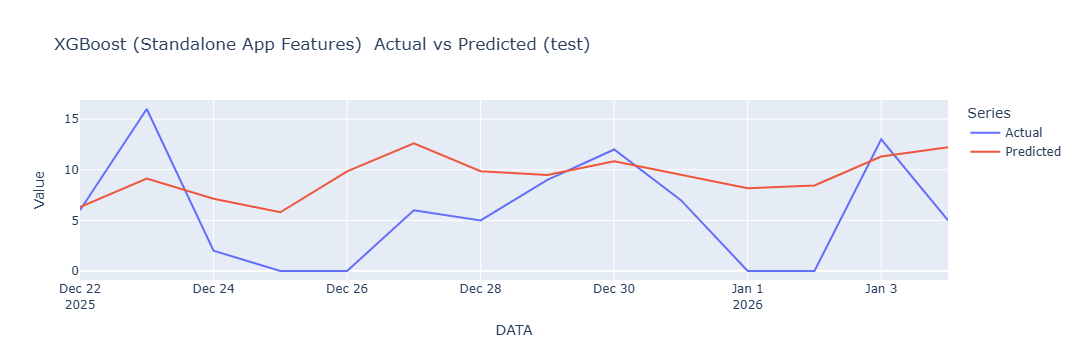

In [9]:
# Plot Actual vs Predicted (test)

df_plot = pd.DataFrame({
    "DATA": test_df["DATA"],
    "Actual": y_test,
    "Predicted": pred
})

df_long = df_plot.melt("DATA", var_name="Series", value_name="Value")

fig = px.line(
    df_long,
    x="DATA",
    y="Value",
    color="Series",
    title="XGBoost (Standalone App Features)  Actual vs Predicted (test)"
)
fig.show()
